In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv("upi_transactions_mixed_upi_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87342 entries, 0 to 87341
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   receiver_upi_id          87342 non-null  object
 1   transaction_type         87342 non-null  object
 2   transaction_time(HH:MM)  87342 non-null  object
 3   date(DD/MM/YYYY)         87342 non-null  object
 4   amount(Rs.)              87342 non-null  int64 
 5   Fraud                    87342 non-null  object
dtypes: int64(1), object(5)
memory usage: 4.0+ MB


In [6]:
df.isnull().sum()

receiver_upi_id            0
transaction_type           0
transaction_time(HH:MM)    0
date(DD/MM/YYYY)           0
amount(Rs.)                0
Fraud                      0
dtype: int64

In [7]:
df.head(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,No
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,Yes
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,Yes
3,kycgee@upi,Requested,03:43,30/10/2021,160373,Yes
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,Yes
5,supportgsx@secure,Requested,18:56,18/07/2020,143828,Yes
6,bharatpe@okhdfc,Debited,05:19,14/05/2017,131115,No


In [8]:
df.columns.tolist()

['receiver_upi_id',
 'transaction_type',
 'transaction_time(HH:MM)',
 'date(DD/MM/YYYY)',
 'amount(Rs.)',
 'Fraud']

In [9]:
df["Fraud"] = df["Fraud"].map({"No":0,"Yes":1})

In [10]:
df['Fraud'].value_counts()

Fraud
1    68021
0    19321
Name: count, dtype: int64

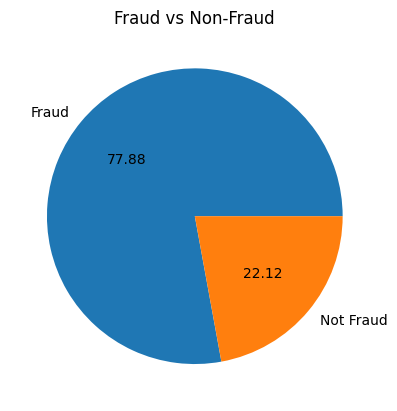

In [11]:
import matplotlib.pyplot as plt
plt.pie(df['Fraud'].value_counts(),labels=['Fraud','Not Fraud'], autopct="%0.2f")
plt.title("Fraud vs Non-Fraud")
plt.show()

In [12]:
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),date(DD/MM/YYYY),amount(Rs.),Fraud
46411,refundhmo@alert,Requested,07:26,30/07/2017,195534,1
66397,nehaverma@ybl,Debited,07:46,22/12/2019,35492,0
15477,refundqyf@fast,Requested,08:51,24/12/2020,191998,1
28248,supportvmt@fast,Requested,07:36,23/08/2018,32209,1
59220,refundxmz@fast,Requested,14:38,06/08/2026,188914,1
2884,cashbackaed@secure,Requested,19:05,23/12/2018,100667,1
3136,claimxmt@secure,Requested,17:51,18/05/2019,109430,1


In [13]:
df.rename(columns={'date(DD/MM/YYYY)':'Date(DD/MM/YYYY)','amount(Rs.)':'Amount(Rs.)','Fraud':'is_Fraud'},inplace=True)
df.sample(7)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud
35907,urgentcki@secure,Requested,19:36,19/01/2019,133128,1
79670,supportoxw@fast,Requested,03:20,02/08/2017,56479,1
44346,claimdym@alert,Debited,12:08,10/01/2020,178552,1
9053,supportmgq@alert,Debited,02:00,22/05/2017,4371,1
26544,amazonpay@okhdfc,Debited,04:21,06/08/2025,43968,0
64358,kavitanair6455@ybl,Debited,13:54,09/05/2023,107177,0
40462,urgentgrn@secure,Requested,10:21,12/06/2016,77835,1


In [14]:
df.duplicated().sum()
#If duplicates were there simply use-> df = df.drop_duplicates(keep='First')

np.int64(0)

In [15]:
df.shape

(87342, 6)

In [16]:
#Exploratory Data Analysis

In [17]:
#column names
#['receiver_upi_id','transaction_type','transaction_time(HH:MM)','date(DD/MM/YYYY)','amount(Rs.)','Fraud']
#receiver_upi_id -- text processing

In [18]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/kaka/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
#Number of words using nltk.word_tokenize(lambda_variable) && then calculate no. of words of each id after tokenize
df['num_words'] = df['receiver_upi_id'].apply(lambda x: len(nltk.word_tokenize(x)))
#all id should have 3 parts as xyz@abc -> [xyz,@,abc]

In [20]:
df['num_char'] = df['receiver_upi_id'].apply(len)

In [21]:
df.head()

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_words,num_char
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,3,14
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,3,13
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,3,17
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,3,10
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,3,14


In [22]:
#df['num_words'] = df['receiver_upi_id'].apply(lambda x: nltk.sent_tokenize(x))
#--> Number of sentences using nltk.sent_tokenize(lambda_variable) && then calculate how much sentences in a row

In [23]:
#Describes values for is_Fraud=0 : Fraud=No(Safe Transaction)
df[df['is_Fraud']==0][['num_char','num_words']].describe()

,num_char,num_words
count,19321.000000,19321.0
mean,14.802753,3.0
std,3.800793,0.0
min,8.000000,3.0
25%,12.000000,3.0
50%,15.000000,3.0
75%,18.000000,3.0
max,24.000000,3.0


In [24]:
#Describes values for is_Fraud=1 : Fraud=Yes(Not Safe Transaction)
df[df['is_Fraud']==1][['num_char','num_words']].describe()

,num_char,num_words
count,68021.000000,68021.0
mean,14.300054,3.0
std,1.653815,0.0
min,10.000000,3.0
25%,13.000000,3.0
50%,14.000000,3.0
75%,15.000000,3.0
max,18.000000,3.0


<Axes: xlabel='num_char', ylabel='Count'>

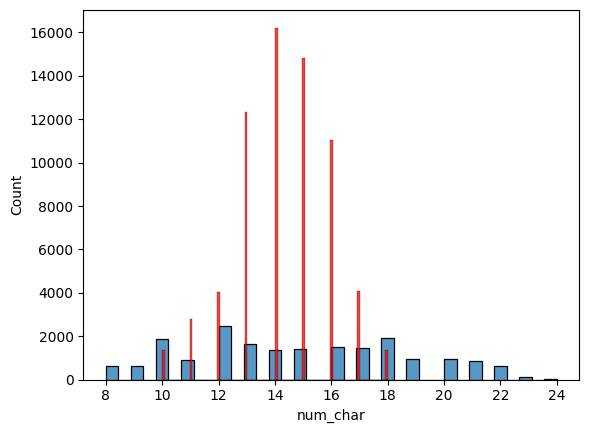

In [25]:
sns.histplot(df[df['is_Fraud']==0]['num_char'])
sns.histplot(df[df['is_Fraud']==1]['num_char'],color='Red')
#R-1: In fraud id: num_char is less but count high
#R-2: In non-fraud id: num_char is more but count is low
#Data Behavioural Representation

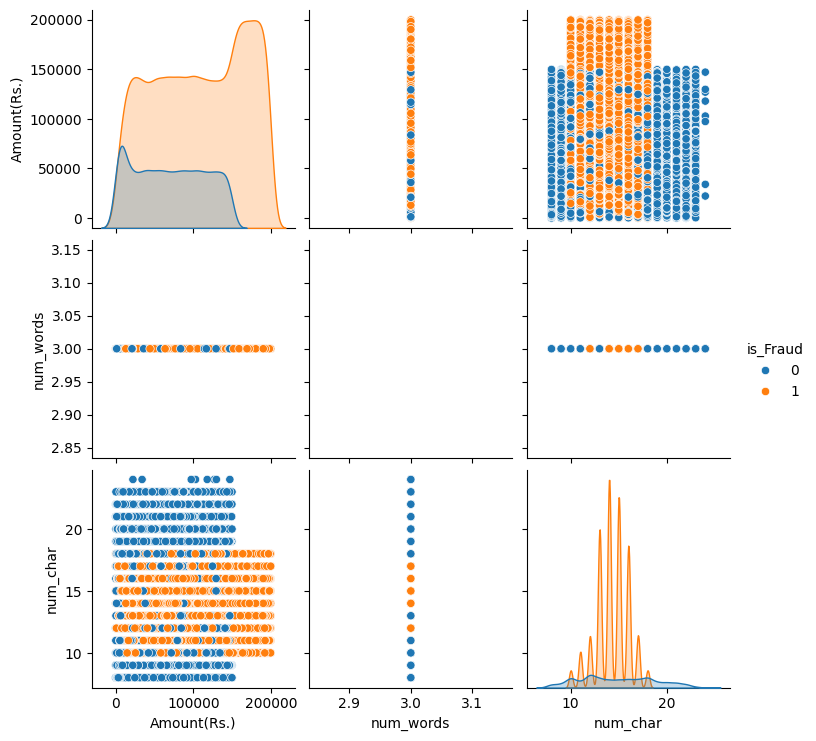

In [26]:
sns.pairplot(df,hue='is_Fraud') #Finds behavioural pattern

<Axes: >

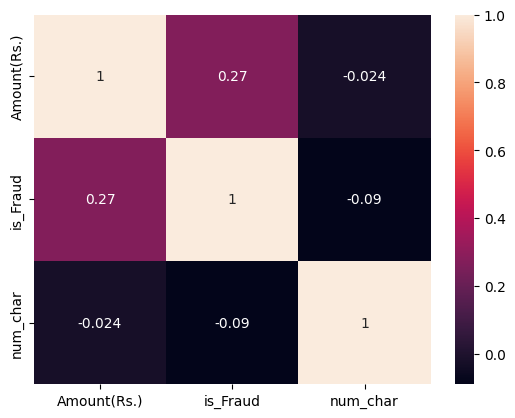

In [27]:
#Find correlation among the features(At first make all of these numeric values)
#Plot it into a heatmap 
df = df.drop(columns=['num_words'])
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [28]:
#Text : UPI ID preprocessing

In [29]:
#Convert abc@xyz -> abcxyz
def transform_text(text):
    text = text.lower() #LowerCase
    text = nltk.word_tokenize(text) #Word Split
    y=[] #Empty list
    for i in text:
        if i.isalnum():
            y.append(i) #Append except '@'
    return "".join(y) #Return as a string, elements seperated with ""

In [30]:
#Convert abc@xyz -> abc xyz
def transform_text_1(text):
    text = text.lower() #LowerCase
    text = nltk.word_tokenize(text) #Word Split
    y=[] #Empty list
    for i in text:
        if i.isalnum():
            y.append(i) #Append except '@'
    return " ".join(y) #Return as a string, elements seperated with " "

In [31]:
transform_text(df['receiver_upi_id'][79])

'rewardyvnsecure'

In [32]:
transform_text_1(df['receiver_upi_id'][79])

'rewardyvn secure'

In [33]:
#Converts entire column into space seperated string without @
#Number of characters in each modified UPI ID
df['new_r_id'] = df['receiver_upi_id'].apply(transform_text) 
df['num_char_modified'] = df['new_r_id'].apply(len)
df['new_r_id_space'] = df['receiver_upi_id'].apply(transform_text_1)

In [34]:
#Import wordcloud and make its object
#Syntax: objectWC = WordCloud(width=x,height=y,min_font_size=a,background_color='color_name')
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [35]:
df.head(3)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id,num_char_modified,new_r_id_space
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharmaybl,13,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpoupi,12,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtcsecure,16,supportgtc secure


In [36]:
#Generate Word Cloud to check significant keywords in upi id
#which are associated with Fraud Transactions("is_Fraud"==1)

In [37]:
#generate wc from ['new_r_id'] where is_Fraud=1, -> .str(converts to string) -> .cat(sep=" ")[Space Seperated]
fraud_wc = wc.generate(df[df['is_Fraud'] == 1]['new_r_id_space'].str.cat(sep=" "))

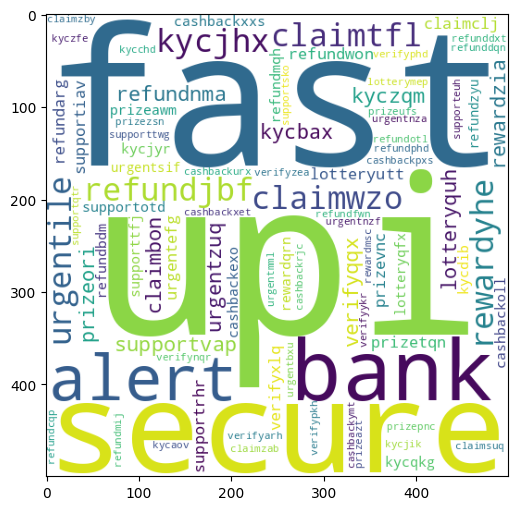

In [38]:
plt.figure(figsize=(15,6))
plt.imshow(fraud_wc)

In [39]:
#Generate Word Cloud to check significant keywords in upi id
#which are associated with Non-Fraud Transactions("is_Fraud"==0)

In [40]:
#generate wc from ['new_r_id'] where is_Fraud=0, -> .str(converts to string) -> .cat(sep=" ")[Space Seperated]
safe_wc = wc.generate(df[df['is_Fraud']==0]['new_r_id_space'].str.cat(sep=" "))

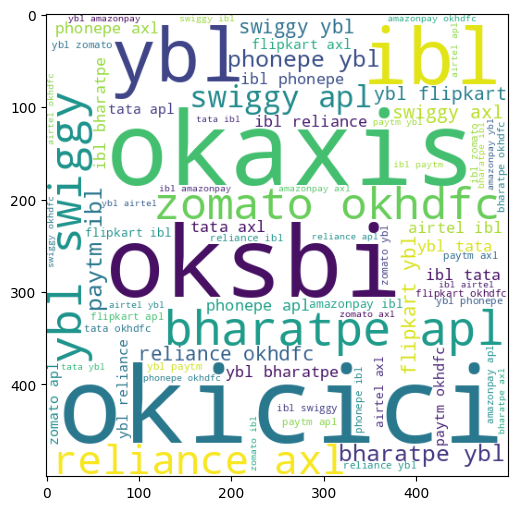

In [41]:
plt.figure(figsize=(15,6))
plt.imshow(safe_wc)

In [42]:
#For is_Fraud=1, convert each values from 'new_r_id' to a single list of Strings
list_1 = df[df['is_Fraud']==1]['new_r_id_space'].tolist()
fraud_corp=[]
#For each message string in list
for msg in list_1:
    #for each word in msg string
    for word in msg.split():
        fraud_corp.append(word) #Add all word elements of all msg elements in a single list

In [43]:
#total words associated with is_Fraud=1
len(fraud_corp)

136042

In [44]:
#Create a dictionary of the frequency of the words
from collections import Counter
#Finds most occured top 50 words with their frequencies --> store it in a dataframe
top_5_fraud_word = pd.DataFrame(Counter(fraud_corp).most_common(5))
top_5_fraud_word

,0,1
0,upi,13682
1,fast,13674
2,secure,13653
3,bank,13578
4,alert,13434


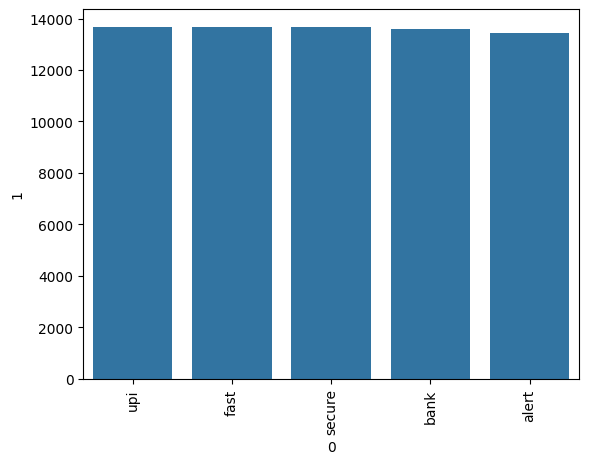

In [45]:
sns.barplot(x=top_5_fraud_word[0],y=top_5_fraud_word[1])
plt.xticks(rotation='vertical')
plt.show()

In [46]:
#For is_Fraud=0, convert each values from 'new_r_id' to a single list of Strings
list_2 = df[df['is_Fraud']==0]['new_r_id_space'].tolist()
safe_corp=[]
#For each message string in list
for msg in list_2:
    #for each word in msg string
    for word in msg.split():
        safe_corp.append(word) #Add all word elements of all msg elements in a single list

In [47]:
#total words associated with is_Fraud=0
len(safe_corp)

38642

In [48]:
#Create a dictionary of the frequency of the words
safe_dict = Counter(safe_corp)
#Finds most occured top 50 words with their frequencies --> store it in a dataframe
top_5_safe_word = pd.DataFrame(Counter(safe_corp).most_common(5))
top_5_safe_word

,0,1
0,ybl,3889
1,ibl,3793
2,oksbi,2346
3,okaxis,2257
4,okicici,2245


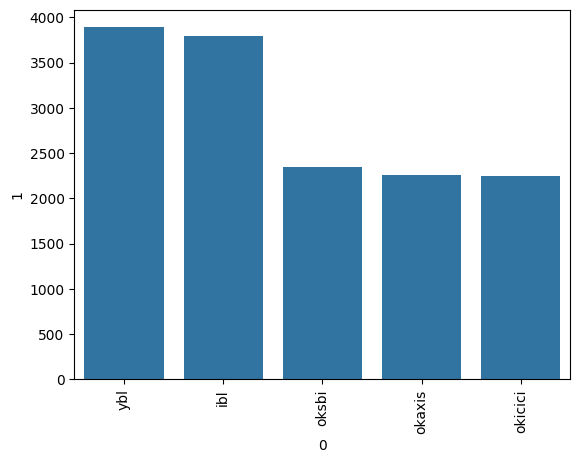

In [49]:
sns.barplot(x=top_5_safe_word[0],y=top_5_safe_word[1])
plt.xticks(rotation='vertical')
plt.show()

In [50]:
#Model Building

In [51]:
df.head(5)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id,num_char_modified,new_r_id_space
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharmaybl,13,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpoupi,12,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtcsecure,16,supportgtc secure
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,kycgeeupi,9,kycgee upi
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,prizeivaalert,13,prizeiva alert


In [52]:
df.head(5)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id,num_char_modified,new_r_id_space
0,amitsharma@ybl,Debited,15:42,11/06/2020,60366,0,14,amitsharmaybl,13,amitsharma ybl
1,urgentxpo@upi,Requested,16:07,25/08/2019,32347,1,13,urgentxpoupi,12,urgentxpo upi
2,supportgtc@secure,Requested,10:26,07/06/2025,150559,1,17,supportgtcsecure,16,supportgtc secure
3,kycgee@upi,Requested,03:43,30/10/2021,160373,1,10,kycgeeupi,9,kycgee upi
4,prizeiva@alert,Requested,01:56,11/09/2023,144160,1,14,prizeivaalert,13,prizeiva alert


In [53]:
#It is an 1-D array with single single element, no need to make a new 1-D list
#Evaluating time when is_Fraud=1
fraud_time_corp = df[df['is_Fraud']==1]['transaction_time(HH:MM)'].tolist()
len(fraud_time_corp)

68021

In [54]:
top_30_fraud_time = pd.DataFrame(Counter(fraud_time_corp).most_common(30))
top_30_fraud_time
#DataFrame format: pd_var[0] = Value of element, pd_var[1] = Freq count of element

,0,1
0,21:41,73
1,09:57,70
2,02:44,69
3,16:24,68
4,06:51,68
5,23:51,66
6,14:03,66
7,13:57,66
8,06:33,66
9,01:53,65


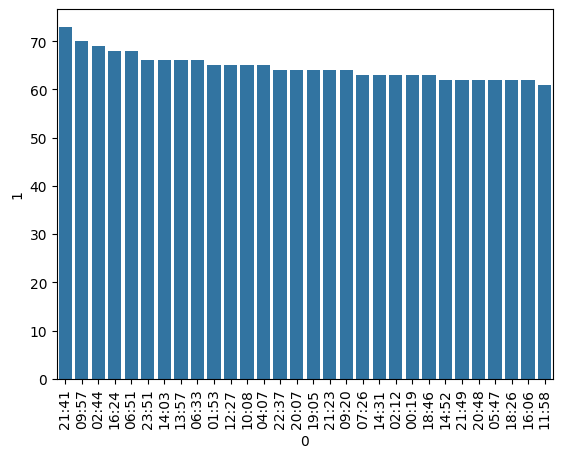

In [55]:
sns.barplot(x=top_30_fraud_time[0],y=top_30_fraud_time[1])
plt.xticks(rotation='vertical')
plt.show()

In [56]:
#It is an 1-D array with single single element, no need to make a new 1-D list
#Evaluating time when is_Fraud=0
safe_time_corp = df[df['is_Fraud']==0]['transaction_time(HH:MM)'].tolist()
len(safe_time_corp)

19321

In [57]:
top_30_safe_time = pd.DataFrame(Counter(safe_time_corp).most_common(30))
top_30_safe_time
#DataFrame format: pd_var[0] = Value of element, pd_var[1] = Freq count of element

,0,1
0,15:10,26
1,12:04,25
2,23:37,25
3,13:52,25
4,21:12,25
5,20:53,24
6,15:43,24
7,20:15,24
8,09:42,23
9,12:43,23


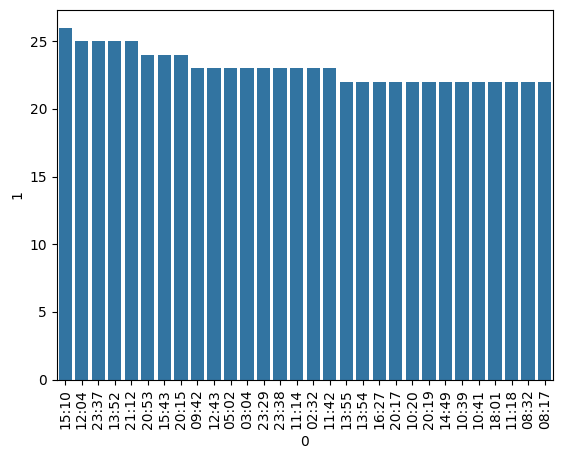

In [58]:
sns.barplot(x=top_30_safe_time[0],y=top_30_safe_time[1])
plt.xticks(rotation='vertical')
plt.show()

In [59]:
fraud_date_corp = df[df['is_Fraud']==1]['Date(DD/MM/YYYY)'].tolist()
len(fraud_date_corp)

68021

In [60]:
top_30_fraud_date = pd.DataFrame(Counter(fraud_date_corp).most_common(30))
top_30_fraud_date

,0,1
0,05/05/2018,36
1,23/07/2021,32
2,29/11/2018,32
3,02/04/2021,31
4,18/11/2020,30
5,11/10/2017,30
6,15/05/2022,30
7,07/07/2016,30
8,27/07/2018,30
9,07/06/2026,30


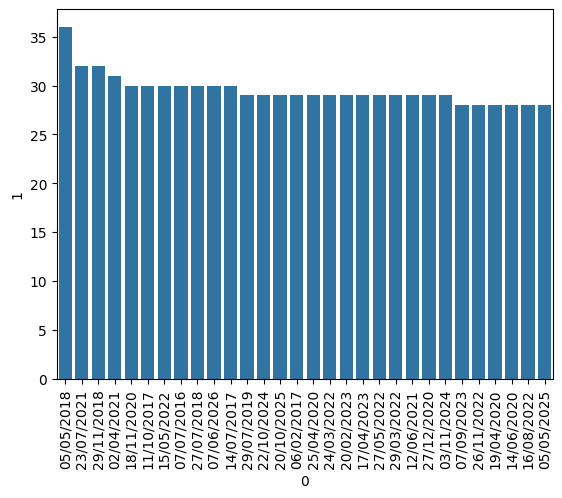

In [61]:
sns.barplot(x=top_30_fraud_date[0],y=top_30_fraud_date[1])
plt.xticks(rotation='vertical')
plt.show()

In [62]:
safe_date_corp = df[df['is_Fraud']==0]['Date(DD/MM/YYYY)'].tolist()
len(safe_date_corp)

19321

In [63]:
top_30_safe_date = pd.DataFrame(Counter(safe_date_corp).most_common(30))
top_30_safe_date

,0,1
0,06/03/2018,14
1,28/03/2022,13
2,20/01/2022,13
3,16/07/2026,12
4,13/08/2020,12
5,10/08/2019,12
6,15/04/2016,12
7,12/03/2020,12
8,31/10/2024,12
9,07/12/2023,12


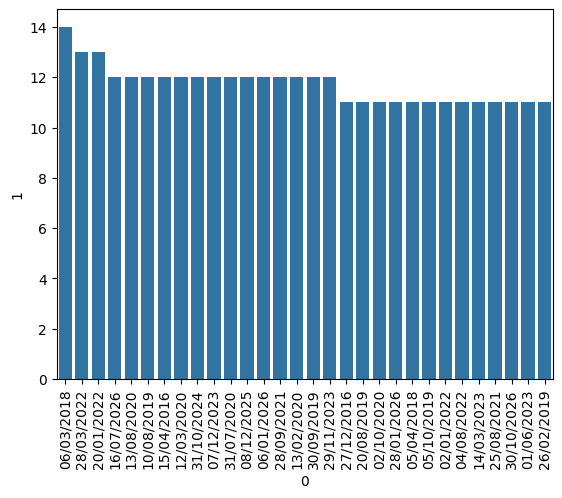

In [64]:
sns.barplot(x=top_30_safe_date[0],y=top_30_safe_date[1])
plt.xticks(rotation='vertical')
plt.show()

In [65]:
df.sample(3)

,receiver_upi_id,transaction_type,transaction_time(HH:MM),Date(DD/MM/YYYY),Amount(Rs.),is_Fraud,num_char,new_r_id,num_char_modified,new_r_id_space
45308,prizeqfb@bank,Debited,04:54,29/01/2023,190892,1,13,prizeqfbbank,12,prizeqfb bank
10658,cashbackvht@alert,Debited,16:57,08/10/2018,14721,1,17,cashbackvhtalert,16,cashbackvht alert
59454,amazonpay@axl,Debited,12:02,29/03/2019,109264,0,13,amazonpayaxl,12,amazonpay axl


In [66]:
#Replaces date '/' : 01/01/2025 -> 01  01 2025
df['Date_mod'] = df['Date(DD/MM/YYYY)'].str.replace('/','').astype(int)

In [67]:
def transform_time(time):
    return int(time.replace(':',''))

In [68]:
df['Time_mod'] = df['transaction_time(HH:MM)'].apply(transform_time)

In [69]:
tr_label = LabelEncoder()
df['Type_mod'] = tr_label.fit_transform(df['transaction_type'])

In [105]:
df_numeric = df[['num_char_modified','new_r_id','Amount(Rs.)','Date_mod','Time_mod','Type_mod','is_Fraud']]
df_numeric.sample(5)

,num_char_modified,new_r_id,Amount(Rs.),Date_mod,Time_mod,Type_mod,is_Fraud
934,12,verifytsnupi,158184,17052025,800,1,1
79696,11,prizeaasupi,28320,16052025,1432,1,1
44208,14,rewardgcgalert,176817,27122023,2030,0,1
52535,20,vikasverma3776okaxis,133279,1102023,1652,0,0
5530,12,prizeckpfast,157654,7082017,1100,1,1


In [106]:
#new_r_id vectorization from now on

In [107]:
corr_df = df_numeric.corr(numeric_only=True)
corr_df['is_Fraud'].sort_values(ascending=False)

is_Fraud             1.000000
Type_mod             0.463048
Amount(Rs.)          0.270456
Date_mod             0.002847
Time_mod            -0.004439
num_char_modified   -0.090048
Name: is_Fraud, dtype: float64

In [108]:
#Model Building and Improvement

In [109]:
from sklearn.feature_extraction.text import CountVectorizer

In [128]:
X = df_numeric.drop('is_Fraud',axis=1)
X

,num_char_modified,new_r_id,Amount,Date_mod,Time_mod,Type_mod
0,13,amitsharmaybl,60366,11062020,1542,0
1,12,urgentxpoupi,32347,25082019,1607,1
2,16,supportgtcsecure,150559,7062025,1026,1
3,9,kycgeeupi,160373,30102021,343,1
4,13,prizeivaalert,144160,11092023,156,1
...,...,...,...,...,...,...
87337,20,snehasingh3897okaxis,1245,15052016,701,0
87338,12,kycxrvsecure,44238,6042019,1813,1
87339,12,amazonpayibl,83736,26092023,1816,0
87340,15,rewardsawsecure,190267,16122020,1033,0


In [129]:
Y = df_numeric['is_Fraud'].values
Y

array([0, 1, 1, ..., 0, 1, 0], shape=(87342,))

In [130]:
df_numeric = df_numeric.copy()
df_numeric.rename(columns={'Amount(Rs.)':'Amount'}, inplace=True)
df_numeric.sample(7)

,num_char_modified,new_r_id,Amount,Date_mod,Time_mod,Type_mod,is_Fraud
897,13,claimtuealert,97898,17092018,2247,1,1
46525,12,airtelokhdfc,22612,28122021,1947,0,0
18423,16,lotterymjtsecure,76228,4082022,1122,1,1
15668,14,anitaroyokaxis,3738,14092022,916,1,0
9455,12,rewardyeuupi,115105,22022020,1946,1,1
34703,17,cashbackobxsecure,165596,31122024,13,1,1
27397,15,supportfbualert,141618,5072022,2143,1,1


In [131]:
text_column = 'new_r_id'
numeric_columns = ['num_char_modified', 'Amount', 'Date_mod', 'Time_mod', 'Type_mod']

In [132]:
#Pipeline creation

In [133]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text',CountVectorizer(),text_column),
        ('num','passthrough',numeric_columns)
    ]
)

In [134]:
#Pipeline for RandomForestClassifier

In [135]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
model_rfc = Pipeline([
    ('preprocessing',preprocessor),
    ('model',RandomForestClassifier())
])

In [136]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
model_rfc.fit(X_train,Y_train)
Y_Pred_rfc = model_rfc.predict(X_test)
print(accuracy_score(Y_test,Y_Pred_rfc))
print(precision_score(Y_test,Y_Pred_rfc))

0.9824260117923178
0.9825018076644975


In [137]:
#Pipeline for DecisionTreeClassifier

In [138]:
from sklearn.tree import DecisionTreeClassifier
model_dtf = Pipeline([
    ('preprocessing',preprocessor),
    ('model',DecisionTreeClassifier())
])

In [139]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
model_dtf.fit(X_train,Y_train)
Y_Pred_dtf = model_dtf.predict(X_test)
print(accuracy_score(Y_test,Y_Pred_dtf))
print(precision_score(Y_test,Y_Pred_dtf))

0.9748125250443643
0.9826137774855723


In [140]:
#Pipeline for KNNClassifier

In [141]:
from sklearn.neighbors import KNeighborsClassifier
model_knc = Pipeline([
    ('preprocessing',preprocessor),
    ('model',KNeighborsClassifier())
])

In [142]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)
model_knc.fit(X_train,Y_train)
Y_Pred_knc = model_knc.predict(X_test)
print(accuracy_score(Y_test,Y_Pred_knc))
print(precision_score(Y_test,Y_Pred_knc))

0.7390234129028564
0.7962600990357049


In [89]:
upi_id = 'akashmetiya2004@oksbi'
print(transform_text(upi_id))
print(len(transform_text(upi_id)))

akashmetiya2004oksbi
20


In [143]:
X.columns.tolist()

['num_char_modified', 'new_r_id', 'Amount', 'Date_mod', 'Time_mod', 'Type_mod']

In [145]:
# Example user input
upi_id = input("Enter upi id: ")
upi_id_mod = transform_text(upi_id)

num_char = len(upi_id_mod)

Date_mod = input("Enter date: ")
date = int(Date_mod.replace('/',''))

amount = input("Enter amount: ")

Time_mod = input("Enter time: ")
time = int(Time_mod.replace(':',''))

Type_mod = input('Enter transaction type(Enter: Requested/Debited): ')
type_tr = tr_label.transform([Type_mod])[0]

user_input = pd.DataFrame({
    'num_char_modified': [num_char], 
    'new_r_id': [upi_id_mod], 
    'Amount': [amount],
    'Date_mod': [date], 
    'Time_mod': [time], 
    'Type_mod': [type_tr]
})
predict = model_rfc.predict(user_input)
if(predict == 1): print("Fraud Detected")
else: print("Safe Transaction")
# Risk score (probability of fraud class = 1)
risk_score = model_rfc.predict_proba(user_input)[0][1]
print("Fraud Risk Score: ", round(risk_score * 100, 2), "%")

Enter upi id:  playstore1.bd@axisbank
Enter date:  10/02/2026
Enter amount:  86.67
Enter time:  9:23
Enter transaction type(Enter: Requested/Debited):  Debited


Safe Transaction
Fraud Risk Score:  30.0 %


In [147]:
import pickle
pickle.dump(model_rfc, open('fraud_detector.pkl', 'wb'))
pickle.dump(tr_label, open('transaction_label.pkl', 'wb'))